In [182]:
import pandas as pd
pd.set_option("display.max_columns", None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

# Flight Status Prediction Notebook — Ready for Your Data

#### This notebook is designed for users who want to predict flight statuses on their own datasets. To help you get started, we have created sample example data within this notebook. Using this example, you can see how the cascade model predicts the status of flights (on_time, delayed, or cancelled). 

#### Simply replace the sample data with your own flight dataset to generate predictions and explore how the model interprets different flight, weather, and operational features.

In [183]:
# Load a few rows of sample data
sample_data = pd.read_csv("sample_data.csv")  # or create a small DataFrame manually
sample_data = sample_data.rename(columns={"Unnamed: 0": "ID"})
sample_data.head()

,ID,dep_hour,Distance,tmpf,vsby,sknt,p01i,relh,gust,month_sin,month_cos,dow_sin,dow_cos,is_early_morning,is_evening,is_summer,is_holiday_season,high_wind,low_visibility,precip_light,precip_moderate,precip_heavy,weather_severity,Airline_enc,Origin_enc,region_enc,weather_source_enc,airline_delay_rate,airline_cancel_rate,airport_delay_rate,airport_cancel_rate,lag1_delay_rate,lag1_cancel_rate,lag1_volume,cancelled_yesterday,hourly_flights,airport_operations,ops_per_runway,num_runways,max_runway_length_ft,airport_elevation,lag1m_carrier_delay,lag1m_weather_delay,lag1m_nas_delay,lag1m_late_aircraft_delay,lag1m_security_delay
0,21453488,10,594.0,82.000000,10.0000,6.384615,0.00,74.2400,0.0,-0.500000,-8.660254e-01,-2.449294e-16,1.000000,0,0,1,0,0,0,0,0,0,0.053205,11,236,2,0,0.169249,0.033405,0.183728,0.010530,0.0,0.0,290.0,0.0,1.0,0.0,0.0,4.0,13016.0,8.0,0.0,0.0,0.0,0.0,0.0
1,21161892,15,414.0,47.000000,10.0000,2.846154,0.00,22.8900,0.0,0.866025,5.000000e-01,-9.749279e-01,-0.222521,0,0,0,0,0,0,0,0,0,0.023718,25,200,3,0,0.181963,0.008317,0.202397,0.010043,0.0,0.0,290.0,0.0,1.0,1590.0,397.5,4.0,14835.0,2181.0,0.0,0.0,0.0,0.0,0.0
2,22254525,11,234.0,51.800000,10.0000,5.200000,0.00,55.9380,0.0,0.500000,-8.660254e-01,-2.449294e-16,1.000000,0,0,0,0,0,0,0,0,0,0.043333,5,165,1,1,0.181603,0.024672,0.210888,0.027771,0.0,0.0,290.0,0.0,1.0,0.0,0.0,2.0,6549.0,439.0,0.0,0.0,0.0,0.0,0.0
3,23947872,8,664.0,42.588889,7.8961,3.582255,0.04,72.1625,18.0,1.000000,6.123234e-17,4.338837e-01,-0.900969,0,0,0,0,0,0,1,0,0,0.177450,16,40,3,1,0.137209,0.017277,0.149541,0.012159,0.0,0.0,290.0,0.0,1.0,0.0,0.0,3.0,10518.0,3652.0,0.0,0.0,0.0,0.0,0.0
4,23466787,11,1492.0,12.900000,10.0000,9.615385,0.00,84.0700,17.0,0.500000,8.660254e-01,4.338837e-01,-0.900969,0,0,0,1,0,0,0,0,0,0.165128,21,99,3,0,0.167771,0.018332,0.209885,0.014461,0.0,0.0,290.0,0.0,1.0,1563.0,260.5,6.0,16000.0,5431.0,0.0,0.0,0.0,0.0,0.0


#### The model is already pretrained, this is where it is getting loaded in and predicting on the sample dataset.

In [184]:
with open("cascade_final.pkl", "rb") as f:
    model = pickle.load(f)

In [185]:
# Load the cascade model dictionary
with open("cascade_final.pkl", "rb") as f:
    model_dict = pickle.load(f)

model_a = model_dict["model_a"]
model_b = model_dict["model_b"]
features = model_dict["features"]
label_map = model_dict["label_map"]  # e.g., {0: 'on_time', 1: 'delayed', 2: 'cancelled'}

def cascade_predict(df):
    """
    Cascade classifier:
    - model_a: predicts 0 (on_time) or 1 (cancelled)
    - model_b: predicts 0 (on_time) or 1 (delayed) for rows predicted on_time by model_a
    Returns DataFrame with 'Prediction' column.
    """
    X = df[features]
    
    # Model A predicts 0 (on_time) or 1 (cancelled)
    preds_a = model_a.predict(X)
    
    final_preds = []

    for i in range(len(X)):
        if preds_a[i] == 1:  # cancelled
            final_preds.append('cancelled')
        else:  # on_time → check model B
            x_row = X.iloc[[i]]
            pred_b = model_b.predict(x_row)[0]  # 0=on_time, 1=delayed
            if pred_b == 0:
                final_preds.append('on_time')
            else:
                final_preds.append('delayed')
    
    df['Prediction'] = final_preds
    return df

# Example usage:
# sample_data = pd.read_csv("new_data.csv")
# result_df = cascade_predict(sample_data)
# print(result_df[['Prediction']])

### Below, we show the feature importances for the two final models. Model A is used to classify cancellations, while Model B is applied to distinguish delayed flights among those predicted as on-time by Model A. Together, these models generate the final predictions of flight status for all flights.

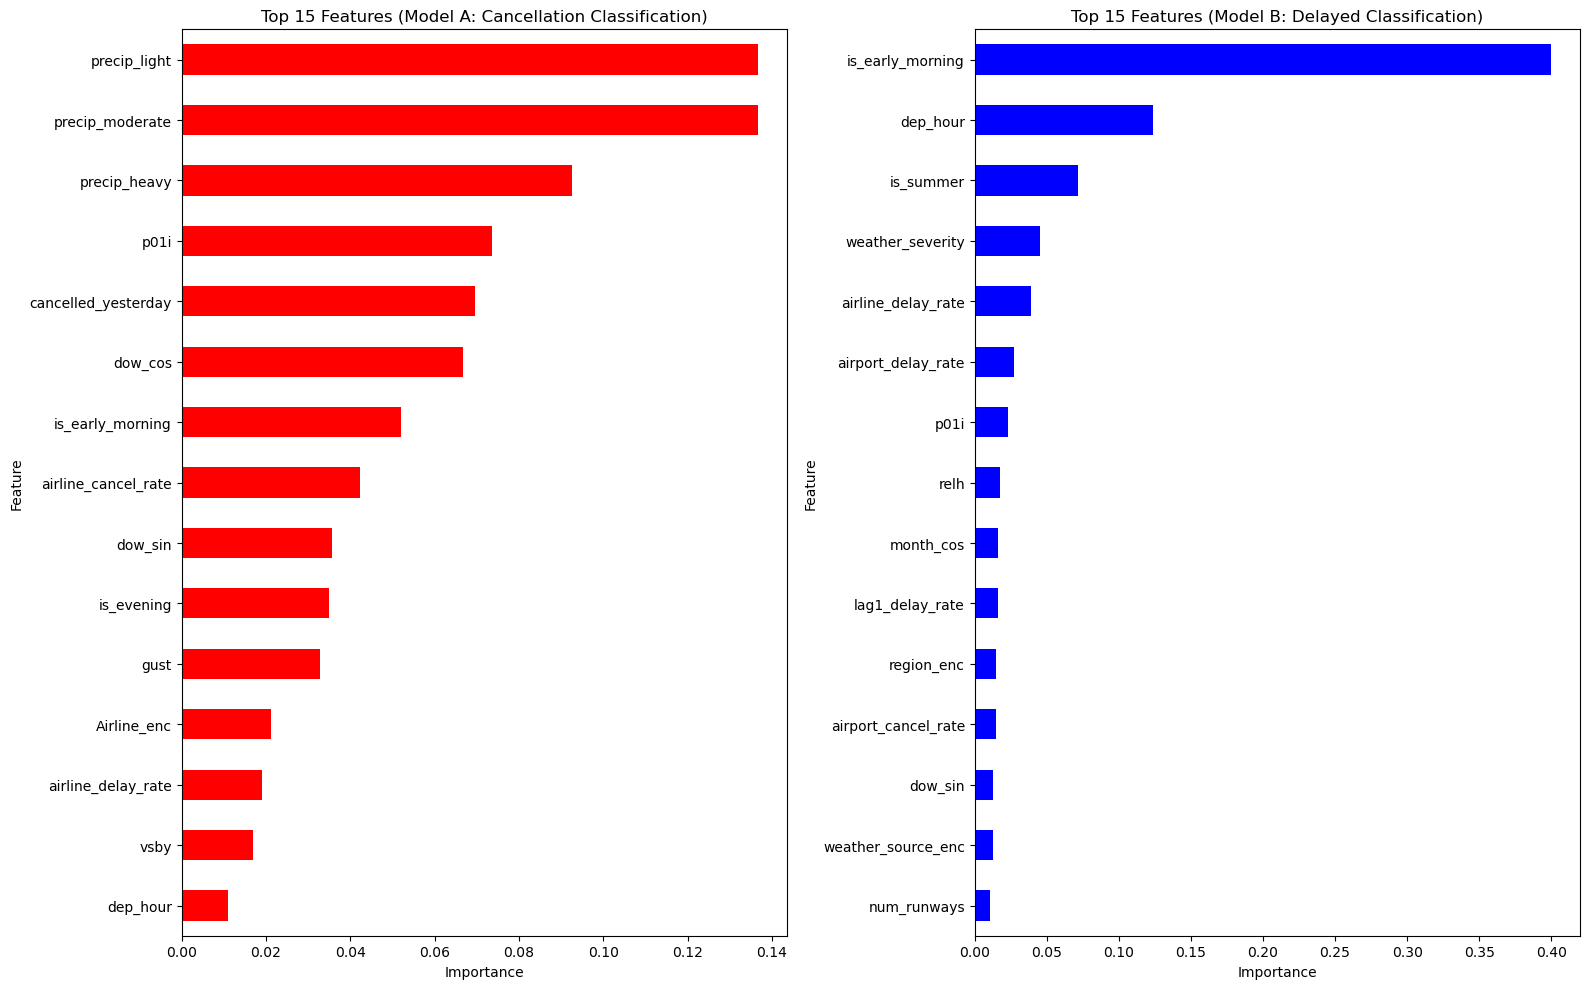

In [197]:
# Feature importances for both models
importance_a = pd.Series(model_a.feature_importances_, index=features).sort_values(ascending=True)
importance_b = pd.Series(model_b.feature_importances_, index=features).sort_values(ascending=True)

# Select top 20 features for each
top_a = importance_a.tail(15)
top_b = importance_b.tail(15)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16,10))

# Model A
top_a.plot(kind="barh", ax=axes[0], color="red")
axes[0].set_title("Top 15 Features (Model A: Cancellation Classification)")
axes[0].set_xlabel("Importance")
axes[0].set_ylabel("Feature")

# Model B
top_b.plot(kind="barh", ax=axes[1], color="blue")
axes[1].set_title("Top 15 Features (Model B: Delayed Classification)")
axes[1].set_xlabel("Importance")
axes[1].set_ylabel("Feature")

plt.tight_layout()
plt.show()

### We see very clearly the feature importance varies depending on the model and what we are trying to classify. As seen, cancellations are usually due more to weather, while delays vary with departure time being the most important features.

# Now let's see what our model predicted for our sample flights

In [186]:
result_df = cascade_predict(sample_data)
print(result_df[["ID","Prediction"]][0:20])

          ID Prediction
0   21453488    on_time
1   21161892    on_time
2   22254525    on_time
3   23947872    on_time
4   23466787    delayed
5   21055262    on_time
6   20255678    on_time
7   22776901    delayed
8   22451260    delayed
9   23379857    delayed
10  21617196    on_time
11  20887061  cancelled
12  23774958    delayed
13  20536718    on_time
14  24067712    on_time
15  21045055    delayed
16  23157894    on_time
17  22803255    delayed
18  23477809    on_time
19  22907643    delayed


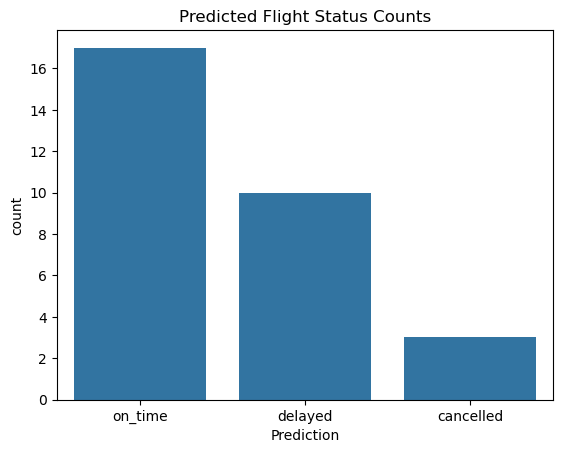

In [187]:
sns.countplot(x="Prediction", data=result_df)
plt.title("Predicted Flight Status Counts")
plt.show()

### PCA Visualization of Model Predictions Using Weather Features
Here we use PCA to reduce the weather features to two dimensions, allowing us to visualize how the model classified flights. This 2D representation makes it easier to understand patterns and relationships in the data.

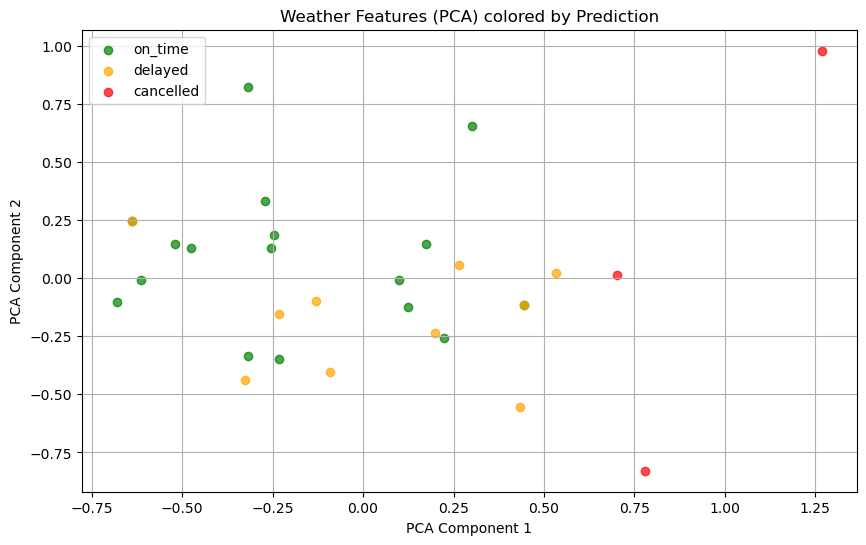

In [188]:
# Features to visualize
weather_features = [
    'tmpf', 'vsby', 'sknt', 'p01i', 'relh', 'gust',
    'high_wind', 'low_visibility', 'precip_light', 'precip_moderate',
    'precip_heavy', 'weather_severity'
]

# Copy dataframe
df_plot = result_df.copy()

# Normalize features to 0-1
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_plot[weather_features])

# Reduce to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot predictions colored by cascade output
plt.figure(figsize=(10,6))
colors = {'on_time':'green', 'delayed':'orange', 'cancelled':'red'}

for label in df_plot['Prediction'].unique():
    mask = df_plot['Prediction'] == label
    plt.scatter(X_pca[mask,0], X_pca[mask,1], label=label, alpha=0.7, color=colors[label])

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Weather Features (PCA) colored by Prediction')
plt.legend()
plt.grid(True)
plt.show()

### PCA Visualization of Model Predictions Using Temporal Features

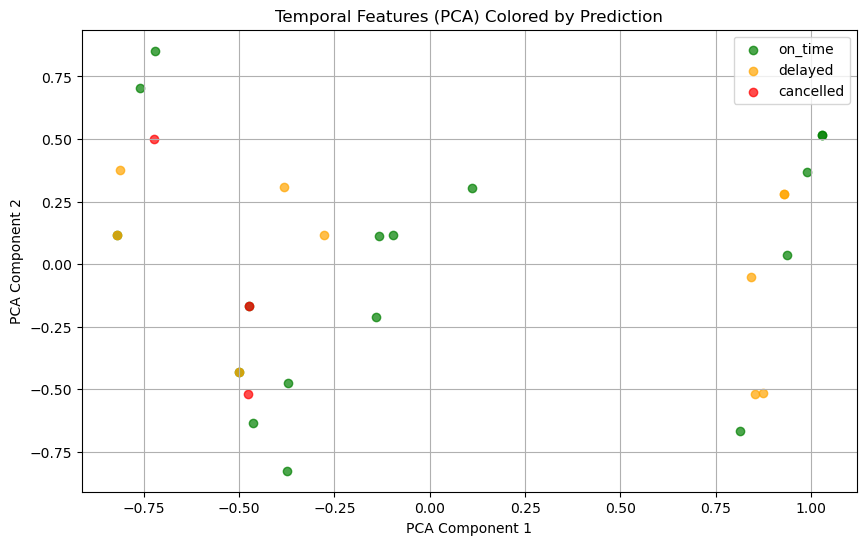

Explained variance ratio: [0.42108555 0.17070677]


In [189]:
temporal_features = [
    'is_early_morning', 'is_evening', 'is_summer', 'is_holiday_season',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos'
]

df_plot = result_df.copy()

# Scale features to 0-1 (mostly useful for sin/cos)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_plot[temporal_features])

# Reduce to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(10,6))

colors = {
    'on_time': 'green',
    'delayed': 'orange',
    'cancelled': 'red'
}

for label in df_plot['Prediction'].unique():
    mask = df_plot['Prediction'] == label
    plt.scatter(
        X_pca[mask,0],
        X_pca[mask,1],
        label=label,
        alpha=0.7,
        color=colors[label]
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Temporal Features (PCA) Colored by Prediction")
plt.legend()
plt.grid(True)
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

#### PCA Visualization of Model Predictions Using Airport Features

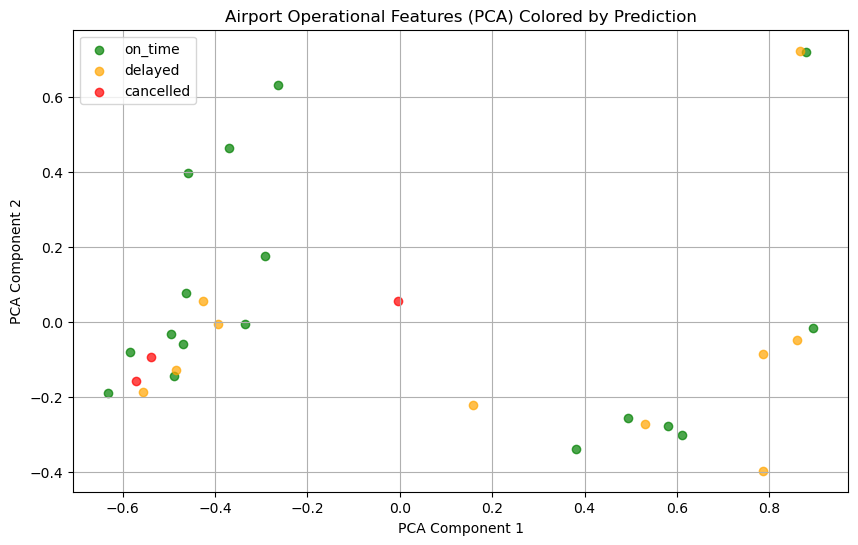

Explained variance ratio: [0.66960962 0.18756106]


In [190]:
airport_features = [
    'airport_operations',
    'ops_per_runway',
    'num_runways',
    'max_runway_length_ft',
    'airport_elevation'
]

df_plot = result_df.copy()

# Scale features 0-1 for plotting
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_plot[airport_features])

# Reduce to 2D with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(10,6))

colors = {
    'on_time': 'green',
    'delayed': 'orange',
    'cancelled': 'red'
}

for label in df_plot['Prediction'].unique():
    mask = df_plot['Prediction'] == label
    plt.scatter(
        X_pca[mask,0],
        X_pca[mask,1],
        label=label,
        alpha=0.7,
        color=colors[label]
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Airport Operational Features (PCA) Colored by Prediction")
plt.legend()
plt.grid(True)
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

## Overview
##### This notebook demonstrates a cascade model that predicts flight statuses as on-time, delayed, or cancelled using weather, temporal, historical, and airport features. 
##### Model A identifies cancellations, while Model B distinguishes delays among flights predicted as on-time. 
##### Visualizations using PCA show clear separations between classes, with cancellations appearing as outliers. 
##### The notebook provides a ready framework to apply the model to your own data and interpret the factors influencing flight outcomes.